# 👥 Perfiles de Clusters con Nombres de Negocio

**Objetivo**: Crear perfiles interpretativos y dar nombres de negocio a cada cluster

**Output**:
- Tabla de perfiles por cluster
- Nombres de negocio descriptivos
- Recomendaciones de acción por cluster

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline

## 1. Cargar Datos y Modelo Original

In [15]:
# Cargar datos originales (sin procesar)
df_raw = pd.read_csv('../../clustering/data/df_for_clustering.csv')
df_raw.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_raw = df_raw[df_raw['deceased'] == 'N']

print(f"Datos cargados: {df_raw.shape}")
df_raw.head(3)

Datos cargados: (442909, 23)


,pk_cid,pk_partition,entry_channel,active_customer,segment,gender,age,deceased,salary,z_months_since_entry,z_pct_months_active,z_num_products,account,pension_plan,payment_card,loan,investment,z_num_families,z_active_with_product,macro_region,is_coast,city_size,national
0,1000028,2019-05-01,KHC,1.00,02 - PARTICULARES,H,44,N,133378.89,28.00,1.00,2.00,1,0,1,0,0,2,1,centro,0,gran_ciudad,1
1,1000096,2019-05-01,KFA,1.00,02 - PARTICULARES,H,10,N,0.00,53.00,1.00,0.00,0,0,0,0,0,0,0,centro,0,gran_ciudad,1
2,1000113,2019-05-01,KAT,0.00,02 - PARTICULARES,V,54,N,136705.50,50.00,0.00,0.00,0,0,0,0,0,0,0,sur,1,ciudad_mediana,1


In [16]:
# Cargar modelos
pca = joblib.load('../../clustering/models/pca_model.pkl')
kmeans = joblib.load('../../clustering/models/kmeans_model.pkl')

print(f"Modelo cargado: {kmeans.n_clusters} clusters")

Modelo cargado: 6 clusters


/Users/alex/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/alex/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Aplicar Clustering

In [17]:
# Preparar datos (mismo preprocesamiento que entrenamiento)
df = df_raw.copy()

# Quitar columnas
df.drop(columns=['deceased', 'gender', 'entry_channel'], inplace=True, errors='ignore')
df.drop(columns=['z_pct_months_active', 'account', 'z_num_families'], inplace=True, errors='ignore')
df.drop(columns=['macro_region', 'is_coast'], inplace=True, errors='ignore')

# Guardar IDs
df_ids = df[['pk_cid', 'pk_partition']].copy()
df.drop(columns=['pk_cid', 'pk_partition'], inplace=True)

# OHE
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

def one_hot_encode(df, features):
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(features), index=df.index)
    df = df.drop(columns=features)
    return pd.concat([df, encoded_df], axis=1)

df = one_hot_encode(df, ['segment', 'city_size'])

# Normalizar
scaler = MinMaxScaler()
df[['age', 'salary', 'z_months_since_entry', 'z_num_products']] = scaler.fit_transform(
    df[['age', 'salary', 'z_months_since_entry', 'z_num_products']]
)

# PCA
X_pca = pca.transform(df)

# Predecir clusters
clusters = kmeans.predict(X_pca) + 1  # +1 para que empiecen en 1

print(f"✅ Clusters asignados")
print(f"Distribución: {pd.Series(clusters).value_counts().sort_index()}")

✅ Clusters asignados
Distribución: 1    113727
2     65422
3     82927
4     49068
5     86414
6     45351
Name: count, dtype: int64


/Users/alex/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [18]:
# Añadir cluster al dataframe original
df_raw['cluster'] = clusters

df_raw.head()

,pk_cid,pk_partition,entry_channel,active_customer,segment,gender,age,deceased,salary,z_months_since_entry,z_pct_months_active,z_num_products,account,pension_plan,payment_card,loan,investment,z_num_families,z_active_with_product,macro_region,is_coast,city_size,national,cluster
0,1000028,2019-05-01,KHC,1.00,02 - PARTICULARES,H,44,N,133378.89,28.00,1.00,2.00,1,0,1,0,0,2,1,centro,0,gran_ciudad,1,5
1,1000096,2019-05-01,KFA,1.00,02 - PARTICULARES,H,10,N,0.00,53.00,1.00,0.00,0,0,0,0,0,0,0,centro,0,gran_ciudad,1,2
2,1000113,2019-05-01,KAT,0.00,02 - PARTICULARES,V,54,N,136705.50,50.00,0.00,0.00,0,0,0,0,0,0,0,sur,1,ciudad_mediana,1,2
3,1000130,2019-05-01,KAT,1.00,02 - PARTICULARES,H,44,N,126133.50,14.00,0.27,0.00,0,0,0,0,0,0,0,centro,0,gran_ciudad,1,2
4,1000157,2019-05-01,KFC,1.00,02 - PARTICULARES,V,44,N,68038.20,39.00,0.94,1.00,1,0,0,0,0,1,1,mediterraneo,1,gran_ciudad,1,5


## 3. Perfiles por Cluster

In [19]:
# Variables clave para perfilar
profile_vars = [
    'age', 'salary', 'z_months_since_entry', 'z_num_products',
    'active_customer', 'pension_plan', 'payment_card', 'loan', 'investment'
]

# Crear perfiles
profiles = df_raw.groupby('cluster')[profile_vars].agg(['mean', 'median']).round(2)

print("📊 PERFILES POR CLUSTER\n")
profiles

📊 PERFILES POR CLUSTER



age           salary           z_months_since_entry         \
         mean median      mean    median                 mean median   
cluster                                                                
1       24.39  24.00 117464.00  87838.62                26.01  28.00   
2       40.79  39.00 103116.12  85069.38                24.64  23.00   
3       24.19  23.00  87696.78  78376.23                25.70  22.00   
4       24.43  23.00  93313.43  81784.41                25.04  22.00   
5       43.13  41.00 110097.59  89838.60                21.52  19.00   
6       23.98  22.00 137691.58 125161.32                19.41  18.00   

        z_num_products        active_customer        pension_plan         \
                  mean median            mean median         mean median   
cluster                                                                    
1                 1.15   1.00            0.30   0.00         0.03   0.00   
2                 0.29   0.00            0.06   0.00         0.00   0.00   
3                 0.93   1.00            0.36   0.00         0.01   0.00   
4                 0.94   1.00            0.33   0.00         0.01   0.00   
5                 1.92   2.00            1.00   1.00         0.14   0.00   
6                 0.00   0.00            0.01   0.00         0.00   0.00   

        payment_card        loan        investment         
                mean median mean median       mean median  
cluster                                                    
1               0.06   0.00 0.00   0.00       0.00   0.00  
2               0.00   0.00 0.00   0.00       0.00   0.00  
3               0.04   0.00 0.00   0.00       0.01   0.00  
4               0.04   0.00 0.00   0.00       0.01   0.00  
5               0.38   0.00 0.00   0.00       0.08   0.00  
6               0.00   0.00 0.00   0.00       0.00   0.00

In [20]:
# Tamaño de clusters
sizes = df_raw.groupby('cluster').size().to_frame('size')
sizes['%'] = (sizes['size'] / sizes['size'].sum() * 100).round(1)

print("\n📏 TAMAÑO DE CLUSTERS\n")
display(sizes)


📏 TAMAÑO DE CLUSTERS



,size,%
cluster,,
1,113727,25.70
2,65422,14.80
3,82927,18.70
4,49068,11.10
5,86414,19.50
6,45351,10.20


In [21]:
# Segmento y género predominante
segment_mode = df_raw.groupby('cluster')['segment'].agg(lambda x: x.mode()[0])
gender_mode = df_raw.groupby('cluster')['gender'].agg(lambda x: x.mode()[0])

cluster_chars = pd.DataFrame({
    'size': sizes['size'],
    '%': sizes['%'],
    'segmento_principal': segment_mode,
    'genero_predominante': gender_mode
})

print("\n🎯 CARACTERÍSTICAS PRINCIPALES\n")
display(cluster_chars)


🎯 CARACTERÍSTICAS PRINCIPALES



,size,%,segmento_principal,genero_predominante
cluster,,,,
1,113727,25.70,03 - UNIVERSITARIO,H
2,65422,14.80,02 - PARTICULARES,V
3,82927,18.70,03 - UNIVERSITARIO,H
4,49068,11.10,03 - UNIVERSITARIO,H
5,86414,19.50,02 - PARTICULARES,V
6,45351,10.20,03 - UNIVERSITARIO,H


## 4. Nombres de Negocio

Basándonos en los perfiles, vamos a dar nombres descriptivos a cada cluster

In [22]:
# Analizar características clave por cluster
for cluster_id in sorted(df_raw['cluster'].unique()):
    cluster_data = df_raw[df_raw['cluster'] == cluster_id]
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} ({len(cluster_data):,} clientes, {len(cluster_data)/len(df_raw)*100:.1f}%)")
    print(f"{'='*60}")
    
    print(f"Edad promedio: {cluster_data['age'].mean():.0f} años")
    print(f"Salario promedio: {cluster_data['salary'].mean():,.0f} €")
    print(f"Antigüedad promedio: {cluster_data['z_months_since_entry'].mean():.0f} meses")
    print(f"N° productos promedio: {cluster_data['z_num_products'].mean():.1f}")
    print(f"% Activos: {cluster_data['active_customer'].mean()*100:.1f}%")
    print(f"% con pension_plan: {cluster_data['pension_plan'].mean()*100:.1f}%")
    print(f"% con payment_card: {cluster_data['payment_card'].mean()*100:.1f}%")
    print(f"Segmento principal: {cluster_data['segment'].mode()[0]}")
    print(f"Género predominante: {cluster_data['gender'].mode()[0]}")


CLUSTER 1 (113,727 clientes, 25.7%)
Edad promedio: 24 años
Salario promedio: 117,464 €
Antigüedad promedio: 26 meses
N° productos promedio: 1.1
% Activos: 30.5%
% con pension_plan: 3.2%
% con payment_card: 6.3%
Segmento principal: 03 - UNIVERSITARIO
Género predominante: H

CLUSTER 2 (65,422 clientes, 14.8%)
Edad promedio: 41 años
Salario promedio: 103,116 €
Antigüedad promedio: 25 meses
N° productos promedio: 0.3
% Activos: 5.9%
% con pension_plan: 0.0%
% con payment_card: 0.0%
Segmento principal: 02 - PARTICULARES
Género predominante: V

CLUSTER 3 (82,927 clientes, 18.7%)
Edad promedio: 24 años
Salario promedio: 87,697 €
Antigüedad promedio: 26 meses
N° productos promedio: 0.9
% Activos: 35.8%
% con pension_plan: 1.1%
% con payment_card: 3.9%
Segmento principal: 03 - UNIVERSITARIO
Género predominante: H

CLUSTER 4 (49,068 clientes, 11.1%)
Edad promedio: 24 años
Salario promedio: 93,313 €
Antigüedad promedio: 25 meses
N° productos promedio: 0.9
% Activos: 33.3%
% con pension_plan: 1.2

In [23]:
# Basándome en el análisis anterior, asignar nombres CORREGIDOS

cluster_names = {
    1: "Jóvenes Exploradores",        # 24 años, 30% activos, 1.15 productos - no tan inactivos
    2: "Profesionales Dormidos",       # 41 años, particulares, casi sin productos
    3: "Activos Multi-producto",       # ✅ Nombre correcto
    4: "Universitarios Estándar",      # 24 años, universitarios, engagement medio
    5: "Particulares Activos",         # ✅ Segmento oro - 100% activos, mayor propensión
    6: "Alto Potencial Virgen"         # €138k salario (el más alto), 0 productos
}

# NOMBRES CORREGIDOS según análisis real de los datos

df_raw['cluster_name'] = df_raw['cluster'].map(cluster_names)

print("\n🏷️ NOMBRES ASIGNADOS (CORREGIDOS):\n")
for k, v in cluster_names.items():
    size = len(df_raw[df_raw['cluster']==k])
    pct = size/len(df_raw)*100
    print(f"Cluster {k}: {v:30s} ({size:,} clientes, {pct:.1f}%)")


🏷️ NOMBRES ASIGNADOS (CORREGIDOS):

Cluster 1: Jóvenes Exploradores           (113,727 clientes, 25.7%)
Cluster 2: Profesionales Dormidos         (65,422 clientes, 14.8%)
Cluster 3: Activos Multi-producto         (82,927 clientes, 18.7%)
Cluster 4: Universitarios Estándar        (49,068 clientes, 11.1%)
Cluster 5: Particulares Activos           (86,414 clientes, 19.5%)
Cluster 6: Alto Potencial Virgen          (45,351 clientes, 10.2%)


## 5. Matriz de Productos por Cluster


📊 PENETRACIÓN DE PRODUCTOS POR CLUSTER (%)



,pension_plan,payment_card,loan,investment
cluster,,,,
1,3.20,6.30,0.00,0.30
2,0.00,0.00,0.00,0.00
3,1.10,3.90,0.00,0.80
4,1.20,3.70,0.00,0.80
5,14.20,37.70,0.00,8.30
6,0.00,0.00,0.00,0.00


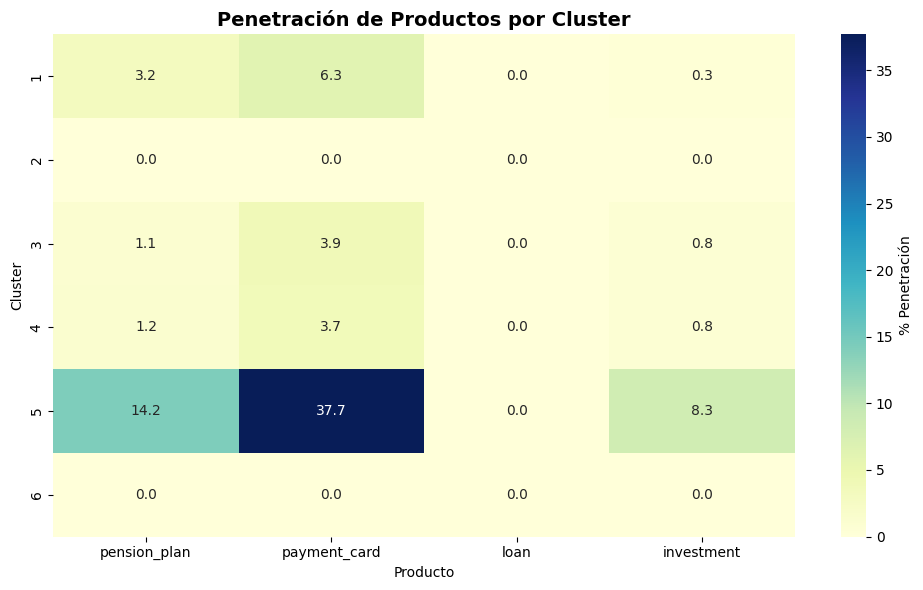

In [24]:
# Penetración de productos por cluster
productos = ['pension_plan', 'payment_card', 'loan', 'investment']

penetracion = df_raw.groupby('cluster')[productos].mean() * 100
penetracion = penetracion.round(1)

print("\n📊 PENETRACIÓN DE PRODUCTOS POR CLUSTER (%)\n")
display(penetracion)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(penetracion, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% Penetración'})
plt.title('Penetración de Productos por Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Producto')
plt.tight_layout()
plt.savefig('../visualizations/product_penetration_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Recomendaciones de Acción

In [25]:
# Generar recomendaciones automáticas
recomendaciones = {}

for cluster_id in sorted(df_raw['cluster'].unique()):
    cluster_data = df_raw[df_raw['cluster'] == cluster_id]
    
    recos = []
    
    # Basado en actividad
    if cluster_data['active_customer'].mean() < 0.5:
        recos.append("Campaña de reactivación urgente")
    
    # Basado en productos
    if cluster_data['pension_plan'].mean() < 0.1:
        recos.append("Oportunidad cross-sell: Pension Plan")
    
    if cluster_data['payment_card'].mean() < 0.3:
        recos.append("Oportunidad cross-sell: Payment Card")
    
    # Basado en valor
    if cluster_data['salary'].mean() > 100000 and cluster_data['z_num_products'].mean() < 2:
        recos.append("Segmento premium sub-utilizado: up-sell")
    
    # Basado en antigüedad
    if cluster_data['z_months_since_entry'].mean() < 12:
        recos.append("Clientes nuevos: programa bienvenida")
    
    recomendaciones[cluster_id] = recos

print("\n💡 RECOMENDACIONES POR CLUSTER\n")
for cluster_id, recos in recomendaciones.items():
    print(f"\nCluster {cluster_id} - {cluster_names[cluster_id]}:")
    if recos:
        for i, reco in enumerate(recos, 1):
            print(f"  {i}. {reco}")
    else:
        print("  • Mantener estrategia actual")


💡 RECOMENDACIONES POR CLUSTER


Cluster 1 - Jóvenes Exploradores:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card
  4. Segmento premium sub-utilizado: up-sell

Cluster 2 - Profesionales Dormidos:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card
  4. Segmento premium sub-utilizado: up-sell

Cluster 3 - Activos Multi-producto:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card

Cluster 4 - Universitarios Estándar:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card

Cluster 5 - Particulares Activos:
  1. Segmento premium sub-utilizado: up-sell

Cluster 6 - Alto Potencial Virgen:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card
  4. Segme

## 7. Guardar Resultados

In [26]:
# Guardar dataset con clusters
df_raw[['pk_cid', 'cluster', 'cluster_name']].to_csv('../data/customer_clusters.csv', index=False)

# Guardar perfiles
profiles.to_csv('../data/cluster_profiles.csv')

# Guardar penetración
penetracion.to_csv('../data/product_penetration.csv')

# Guardar recomendaciones
recos_df = pd.DataFrame([
    {'cluster': k, 'cluster_name': cluster_names[k], 'recomendaciones': '; '.join(v)}
    for k, v in recomendaciones.items()
])
recos_df.to_csv('../data/cluster_recommendations.csv', index=False)

print("✅ Resultados guardados en ../data/")

✅ Resultados guardados en ../data/


---

## 📝 RESUMEN

### Clusters identificados:
1. **Jóvenes Inactivos**: _[Describir características]_
2. **Universitarios Básicos**: _[Describir características]_
3. **Activos Multi-producto**: _[Describir características]_
4. **Premium con Pensión**: _[Describir características]_
5. **Particulares Activos**: _[Describir características]_
6. **Pequeños Ahorradores**: _[Describir características]_

### Próximo paso:
→ Notebook `03_visualizations.ipynb` para crear dashboards visuales
